# Problema 1


Tomamos los modelos base de las clases, a los cuales añadimos una función evalP, la cual nos permite evaluar la probabilidad de observar una imagen $p(x)$, además de una función de entrenamiento.

Cargamos MNIST y creamos los loaders de entrenamiento y prueba

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as tt
import torch.nn.functional as F
import torch.distributions as td
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from torchvision import datasets, transforms

In [2]:
transform=transforms.Compose([
    transforms.ToTensor(),
])
dataset_train = datasets.MNIST('data/', train=True, download=True,transform=transform)
dataset_test = datasets.MNIST('data/', train=False, transform=transform)
training_loader = torch.utils.data.DataLoader(dataset_train,batch_size=1024)
testing_loader = torch.utils.data.DataLoader(dataset_test,batch_size=1024)

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 9912422/9912422 [00:01<00:00, 6268939.18it/s]


Extracting data/MNIST/raw/train-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 28881/28881 [00:00<00:00, 326972.24it/s]


Extracting data/MNIST/raw/train-labels-idx1-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 1648877/1648877 [00:00<00:00, 2701441.99it/s]


Extracting data/MNIST/raw/t10k-images-idx3-ubyte.gz to data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████| 4542/4542 [00:00<00:00, 6705571.55it/s]

Extracting data/MNIST/raw/t10k-labels-idx1-ubyte.gz to data/MNIST/raw



Iniciamos con la mezcla de Gaussianas

In [3]:
class LowerTriangularPositive(nn.Module):

    def __init__(self, K, D):
        super().__init__()
        # Diagonal terms initialized at one
        diags = torch.diag(torch.ones((D))).repeat(K,1,1)
        outdiags = 0.01*torch.randn(K, D, D)
        self.tril = nn.Parameter(diags+outdiags)
        self.register_buffer('mask', torch.tril(torch.ones(D, D), diagonal=-1))
        self.register_buffer('diag_mask', torch.diag(torch.ones(D)))

    def forward(self):
        L = torch.zeros_like(self.tril)
        for i in range(self.tril.shape[0]):
            L[i] = self.tril[i] * self.mask
            L[i] = L[i] + self.diag_mask * torch.sigmoid(self.tril[i].diag()).diag() # Ensure positive diagonal
        return L

In [4]:
class MoG(nn.Module):

    def __init__(self, D, K):
        super(MoG, self).__init__()
        # hyperparams
        self.D = D # the dimensionality of the input
        self.K = K # the number of components
        # params
        self.M = nn.Parameter(torch.sigmoid(torch.randn(self.K, self.D)))
        self.L = LowerTriangularPositive(self.K, self.D)
        self.pi = nn.Parameter(torch.zeros(1, self.K))

    def log_diag_normal(self, x, mu, L, reduction='sum', dim=1):
        m = td.MultivariateNormal(loc=mu,scale_tril=L)
        return m.log_prob(x)

    def forward(self, x):
        x = x.reshape(-1,1,self.D)
        # calculate components
        log_pi = torch.log(F.softmax(self.pi, 1)) # B x K
        log_N = torch.zeros(x.shape[0],self.K,device=x.device) # B x K
        Lt = self.L()
        for i in range(self.K):
            log_N[:,i:i+1] = self.log_diag_normal(x, torch.sigmoid(self.M[i]),Lt[i])
        NLL_loss = -torch.logsumexp(log_pi + log_N, 1) # B
        return NLL_loss.mean()

    def sample(self, batch_size=6):
        # init an empty tensor
        x_sample = torch.empty(batch_size, self.D)
        # First, sample components
        pi = F.softmax(self.pi, 1) # 1 x K, softmax is used for R^K -> [0,1]^K s.t. sum(pi) = 1
        indices = torch.multinomial(pi, batch_size, replacement=True).squeeze()
        # Then, sample the x given the component
        for n in range(batch_size):
            indx = torch.multinomial(pi, 1, replacement=True).squeeze()
            Lt = self.L()[indx]
            m = td.MultivariateNormal(loc=torch.sigmoid(self.M[indx]),scale_tril=Lt)
            x_sample[n] = m.rsample()
        return x_sample

    def evalP(self, x):
        x = x.reshape(-1,1,self.D)
        # calculate components
        log_pi = torch.log(F.softmax(self.pi, 1)) # B x K
        log_N = torch.zeros(x.shape[0],self.K,device=x.device) # B x K
        Lt = self.L()
        for i in range(self.K):
            log_N[:,i:i+1] = self.log_diag_normal(x, torch.sigmoid(self.M[i]),Lt[i])
        log_prob = torch.logsumexp(log_pi + log_N, 1) # B
        prob = torch.exp(log_prob)
        return prob.squeeze(), log_prob.squeeze()

Esta función de entrenamiento es la provista en las notas

In [5]:
def training(name, num_epochs, model, optimizer, training_loader):
    nll_min = 0
    # Main loop
    for e in range(num_epochs):
        # TRAINING
        model.train()
        for indx_batch, batch in enumerate(training_loader):
            x,y = batch
            x = x.to('cuda')
            loss = model.forward(x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"{e:03d} {loss.detach().cpu().item():04.4f}")
        if e==0:
            nll_min = loss.item()
        if (loss.item()<nll_min):
            nll_min = loss.item()
            torch.save(model, name + '.model')

In [6]:
D = 784 # input dimension
K = 15 # the number of neurons in scale (s) and translation (t) nets
lr= 1e-4 # learning rate
num_epochs = 500 # max. number of epochs
name = 'mog'

In [7]:
# Eventually, we initialize the full model
model = MoG(D=D, K=K)
model = model.to("cuda")
# Optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

In [8]:
training(name, num_epochs, model, optimizer, training_loader)

000 540.5712
001 521.7341
002 510.9391
003 504.9285
004 500.5543
005 496.9943
006 493.8918
007 491.0815
008 488.4781
009 486.0309
010 483.7069
011 481.4825
012 479.3398
013 477.2650
014 475.2467
015 473.2758
016 471.3450
017 469.4480
018 467.5797
019 465.7356
020 463.9122
021 462.1063
022 460.3153
023 458.5369
024 456.7691
025 455.0101
026 453.2586
027 451.5130
028 449.7719
029 448.0340
030 446.2976
031 444.5605
032 442.8191
033 441.0681
034 439.3007
035 437.5101
036 435.6974
037 433.8770
038 432.0603
039 430.2495
040 428.4437
041 426.6416
042 424.8423
043 423.0450
044 421.2491
045 419.4539
046 417.6590
047 415.8637
048 414.0680
049 412.2712
050 410.4731
051 408.6733
052 406.8717
053 405.0678
054 403.2616
055 401.4529
056 399.6413
057 397.8268
058 396.0091
059 394.1882
060 392.3640
061 390.5361
062 388.7048
063 386.8698
064 385.0310
065 383.1884
066 381.3419
067 379.4916
068 377.6373
069 375.7791
070 373.9168
071 372.0506
072 370.1804
073 368.3061
074 366.4278
075 364.5455
076 362.6590

<ipython-input-9-4cfb2d55f9af>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best = torch.load(name + '.model')


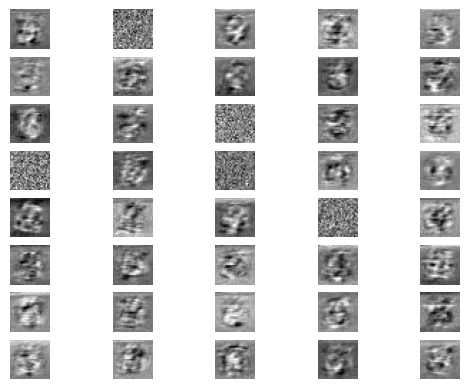

Mean p(x) on test set: inf


In [9]:
with torch.no_grad():
    model_best = torch.load(name + '.model')
    num_x = 8
    num_y = 5
    x = model_best.sample(batch_size=num_x * num_y)
    x = x.detach().numpy()
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to(model_best.M.device)  # Flatten and move to correct device
        px, _ = model_best.evalP(x)
        px_list.append(px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {px_all.mean().item():.6f}")

In [10]:
# A very simple Sigmoid Belief Network (SBN) model
# This model uses a logistic regression-like approach
# to model the probability of binary variables.
class FullyVisibleSigmoidBeliefNetwork(torch.nn.Module):
    def __init__(self, input_size):
        super(FullyVisibleSigmoidBeliefNetwork, self).__init__()
        self.input_size = input_size
        self.register_buffer('autoregressive_mask', torch.tril(torch.ones(input_size, input_size), diagonal=-1))
        # Define the logistic regression weights and bias
        self.lr_weights = torch.nn.Parameter(torch.randn(input_size,input_size))
        self.lt_bias = torch.nn.Parameter(torch.randn(input_size))
        # Activation function
        self.sigmoid = nn.Sigmoid()
    # Forward pass of the model
    def forward(self, x):
        # We use a small epsilon to avoid log(0) issues
        # Forward pass evaluates the probability of an x given the alphas
        logits = nn.functional.linear(x,self.lr_weights*self.autoregressive_mask,self.lt_bias)
        return logits
    # Sample from the model
    def sample(self, num_samples):
        samples = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        probs = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        for i in range(self.input_size):
            prob = self.sigmoid(self.forward(samples))
            probs[:, i] = prob[:, i]
            # Sample from the Bernoulli distribution
            samples[:, i] = torch.bernoulli(prob[:, i])
        return samples,probs
    # Calculate p(x) and log p(x) for a given input x
    def evalP(self, x):
        """
        Evaluate the probability p(x) for a given input x.
        x: torch.Tensor of shape [input_size] or [1, input_size]
        Returns: probability p(x) and log-probability log p(x)
        """
        if x.ndim == 1:
            x = x.unsqueeze(0)
        logits = self.forward(x)
        prob_vec = torch.sigmoid(logits)
        # For binary data, p(x) = prod_i p_i^x_i * (1-p_i)^(1-x_i)
        p_x = torch.prod(prob_vec * x + (1 - prob_vec) * (1 - x), dim=1)
        log_p_x = torch.sum(x * torch.log(prob_vec + 1e-8) + (1 - x) * torch.log(1 - prob_vec + 1e-8), dim=1)
        return p_x.squeeze(), log_p_x.squeeze()

In [11]:
def train_models(name, num_epochs, model, optimizer, training_loader):
    min_loss = float('inf')
    for epoch in range(num_epochs):
        model.train()
        for batch_idx, (x, y) in enumerate(training_loader):
            x = x.view(x.size(0), -1).to("cuda")  # Flatten MNIST images
            logits = model(x)
            # Binary cross-entropy loss
            loss = F.binary_cross_entropy_with_logits(logits, x)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(name + f" Epoch {epoch:03d} Loss: {loss.item():.4f}")
        if loss.item() < min_loss:
            min_loss = loss.item()
            torch.save(model, name + '.model')

In [12]:
# Create a FullyVisibleSigmoidBeliefNetwork for MNIST data
sbn_model = FullyVisibleSigmoidBeliefNetwork(input_size=D).to("cuda")
sbn_optimizer = torch.optim.Adam(sbn_model.parameters(), lr=lr)

# Training loop for SBN model
num_epochs_sbn = 800

train_models('SBN', num_epochs_sbn, sbn_model, sbn_optimizer, training_loader)

SBN Epoch 000 Loss: 2.4641
SBN Epoch 001 Loss: 2.3481
SBN Epoch 002 Loss: 2.2400
SBN Epoch 003 Loss: 2.1393
SBN Epoch 004 Loss: 2.0455
SBN Epoch 005 Loss: 1.9581
SBN Epoch 006 Loss: 1.8765
SBN Epoch 007 Loss: 1.8005
SBN Epoch 008 Loss: 1.7296
SBN Epoch 009 Loss: 1.6634
SBN Epoch 010 Loss: 1.6016
SBN Epoch 011 Loss: 1.5438
SBN Epoch 012 Loss: 1.4898
SBN Epoch 013 Loss: 1.4394
SBN Epoch 014 Loss: 1.3922
SBN Epoch 015 Loss: 1.3480
SBN Epoch 016 Loss: 1.3066
SBN Epoch 017 Loss: 1.2679
SBN Epoch 018 Loss: 1.2315
SBN Epoch 019 Loss: 1.1974
SBN Epoch 020 Loss: 1.1653
SBN Epoch 021 Loss: 1.1352
SBN Epoch 022 Loss: 1.1068
SBN Epoch 023 Loss: 1.0801
SBN Epoch 024 Loss: 1.0549
SBN Epoch 025 Loss: 1.0311
SBN Epoch 026 Loss: 1.0086
SBN Epoch 027 Loss: 0.9873
SBN Epoch 028 Loss: 0.9670
SBN Epoch 029 Loss: 0.9479
SBN Epoch 030 Loss: 0.9296
SBN Epoch 031 Loss: 0.9123
SBN Epoch 032 Loss: 0.8958
SBN Epoch 033 Loss: 0.8800
SBN Epoch 034 Loss: 0.8649
SBN Epoch 035 Loss: 0.8505
SBN Epoch 036 Loss: 0.8368
S

<ipython-input-13-cd24c4752d87>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best = torch.load('SBN.model')


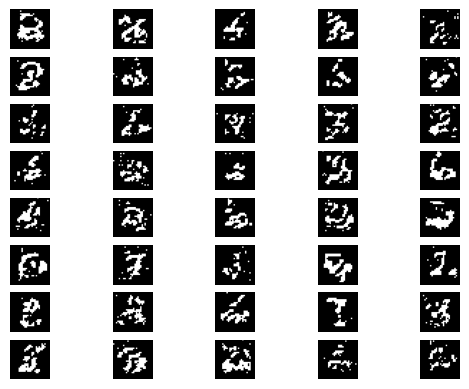

Mean p(x) on test set: 0.000000


In [13]:
with torch.no_grad():
    model_best = torch.load('SBN.model')
    num_x = 8
    num_y = 5
    x = model_best.sample(num_samples=num_x * num_y)
    x = x[0].cpu().detach().numpy()  # Move tensor to CPU before converting to numpy
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to('cuda')  # Flatten and move to correct device
        _, log_px = model_best.evalP(x)
        px_list.append(log_px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {torch.exp(px_all).mean().item():.6f}")

In [ ]:
class NADE(torch.nn.Module):

    def __init__(self, input_size, internal_size=512):
        super(NADE, self).__init__()
        self.input_size = input_size
        self.internal_size = internal_size
        self.register_buffer('autoregressive_mask', torch.tril(torch.ones(input_size, input_size), diagonal=-1))
        self.mlp_weights = torch.nn.Parameter(torch.zeros(self.internal_size,input_size))
        self.mlp_bias = torch.nn.Parameter(torch.zeros(self.internal_size))
        # Define the logistic regression weights and bias
        self.lr_weights = torch.nn.Parameter(torch.zeros(input_size,self.internal_size))
        self.lr_bias = torch.nn.Parameter(torch.zeros(input_size))
        nn.init.kaiming_normal_(self.mlp_weights)
        nn.init.kaiming_normal_(self.lr_weights)
        # Activation functions
        self.activation = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    # Forward pass of the model
    def forward(self, x):
        # We use a small epsilon to avoid log(0) issues
        epsilon = 0.00001
        # Forward pass evaluates the probability of an x given the alphas
        xn = self.autoregressive_mask*x.unsqueeze(1).repeat(1, self.input_size, 1) # Repeat x for input size
        # Random tensor of the same size as xn
        h = self.activation(nn.functional.linear(xn, self.mlp_weights,self.mlp_bias))
        # Logits
        sp = torch.sum(h*self.lr_weights,dim=2)+self.lr_bias
        return sp
    
    # Sample from the model
    def sample(self, num_samples):
        samples = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        probs = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)
            probs[:, i] = prob[:,i]
            # Sample from the Bernoulli distribution
            samples[:, i] = torch.bernoulli(probs[:, i])
        return samples, probs


    def evalP(self, x):
        # x: [num_samples, input_size] (observed images)
        probs = torch.zeros(x.shape[0], self.input_size).to(self.lr_weights.device)
        samples = torch.zeros_like(x).to(self.lr_weights.device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)[:, i]
            # Use the actual observed value for probability
            probs[:, i] = prob * x[:, i] + (1 - prob) * (1 - x[:, i])
            samples[:, i] = x[:, i]  # Set to observed value
        p_x = torch.prod(probs, dim=1)
        log_p_x = torch.sum(torch.log(probs + 1e-8), dim=1)
        return p_x, log_p_x

In [15]:
# Train NADE model using Adam optimizer and binary cross-entropy loss on MNIST data
nade_model = NADE(input_size=D, internal_size=512).to("cuda")
nade_optimizer = torch.optim.Adam(nade_model.parameters(), lr=lr)

# Training loop for NADE
num_epochs_nade = 500

train_models('NADE', num_epochs_nade, nade_model, nade_optimizer, training_loader)

NADE Epoch 000 Loss: 0.3416
NADE Epoch 001 Loss: 0.2929
NADE Epoch 002 Loss: 0.2827
NADE Epoch 003 Loss: 0.2787
NADE Epoch 004 Loss: 0.2765
NADE Epoch 005 Loss: 0.2752
NADE Epoch 006 Loss: 0.2743
NADE Epoch 007 Loss: 0.2737
NADE Epoch 008 Loss: 0.2732
NADE Epoch 009 Loss: 0.2728
NADE Epoch 010 Loss: 0.2724
NADE Epoch 011 Loss: 0.2721
NADE Epoch 012 Loss: 0.2719
NADE Epoch 013 Loss: 0.2716
NADE Epoch 014 Loss: 0.2714
NADE Epoch 015 Loss: 0.2712
NADE Epoch 016 Loss: 0.2710
NADE Epoch 017 Loss: 0.2709
NADE Epoch 018 Loss: 0.2707
NADE Epoch 019 Loss: 0.2705
NADE Epoch 020 Loss: 0.2704
NADE Epoch 021 Loss: 0.2702
NADE Epoch 022 Loss: 0.2701
NADE Epoch 023 Loss: 0.2700
NADE Epoch 024 Loss: 0.2698
NADE Epoch 025 Loss: 0.2697
NADE Epoch 026 Loss: 0.2696
NADE Epoch 027 Loss: 0.2695
NADE Epoch 028 Loss: 0.2694
NADE Epoch 029 Loss: 0.2692
NADE Epoch 030 Loss: 0.2691
NADE Epoch 031 Loss: 0.2690
NADE Epoch 032 Loss: 0.2689
NADE Epoch 033 Loss: 0.2688
NADE Epoch 034 Loss: 0.2687
NADE Epoch 035 Loss:

<ipython-input-16-29fbcb1c385b>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best = torch.load('NADE.model')


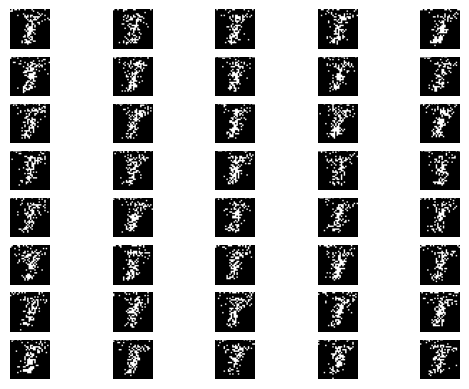

Mean p(x) on test set: 0.000000


In [16]:
with torch.no_grad():
    model_best = torch.load('NADE.model')
    num_x = 8
    num_y = 5
    x = model_best.sample(num_samples=num_x * num_y)
    x = x[0].cpu().detach().numpy()  # Move tensor to CPU before converting to numpy
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to('cuda')  # Flatten and move to correct device
        _, log_px = model_best.evalP(x)
        px_list.append(log_px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {torch.exp(px_all).mean().item():.6f}")

In [17]:
class NADERnn(nn.Module):
    def __init__(self, input_size, internal_size=64):
        super().__init__()
        self.input_size = input_size
        self.internal_size = internal_size
        self.rnn = nn.GRU(1, internal_size, num_layers=1, batch_first=True)

        # Output weights: one logit per pixel
        self.lr_weights = nn.Parameter(torch.empty(input_size, internal_size))
        self.lr_bias = nn.Parameter(torch.zeros(input_size))

        nn.init.kaiming_normal_(self.lr_weights)
        self.activation = nn.Tanh()

    def forward(self, x):
        """
        Teacher-forced forward pass.
        Autoregressively predicts probabilities for each dimension.
        """
        batch_size = x.size(0)
        h = torch.zeros(1, batch_size, self.internal_size, device=x.device)

        probs = []
        for i in range(self.input_size):
            if i == 0:
                # First pixel: no input yet, just use h0
                h_t = self.activation(h[0])  # [batch, hidden]
            else:
                # Feed previous true pixel into GRU
                out, h = self.rnn(x[:, i-1:i].unsqueeze(-1), h)  # [batch, 1, hidden]
                h_t = self.activation(out[:, -1, :])  # [batch, hidden]

            # Predict prob for pixel i
            logit = h_t @ self.lr_weights[i].unsqueeze(1) + self.lr_bias[i]
            prob = torch.sigmoid(logit)
            probs.append(prob)

        return torch.cat(probs, dim=1)  # [batch, input_size]

    def sample(self, num_samples):
        """
        Sequential ancestral sampling.
        """
        device = self.lr_weights.device
        samples = torch.zeros(num_samples, self.input_size, device=device)
        probs = torch.zeros_like(samples)

        h = torch.zeros(1, num_samples, self.internal_size, device=device)

        for i in range(self.input_size):
            if i == 0:
                h_t = self.activation(h[0])
            else:
                out, h = self.rnn(samples[:, i-1:i].unsqueeze(-1), h)
                h_t = self.activation(out[:, -1, :])

            logit = h_t @ self.lr_weights[i].unsqueeze(1) + self.lr_bias[i]
            prob = torch.sigmoid(logit).squeeze(-1)
            probs[:, i] = prob
            samples[:, i] = torch.bernoulli(prob)

        return samples, probs

    def evalP(self, x):
        """
        Compute p(x) and log p(x).
        """
        if x.ndim == 1:
            x = x.unsqueeze(0)

        prob_vec = self.forward(x)
        p_x = torch.prod(prob_vec * x + (1 - prob_vec) * (1 - x), dim=1)
        log_p_x = torch.sum(
            x * torch.log(prob_vec + 1e-8) +
            (1 - x) * torch.log(1 - prob_vec + 1e-8),
            dim=1
        )
        return p_x.squeeze(), log_p_x.squeeze()


In [18]:
# Train NADERnn model using Adam optimizer and binary cross-entropy loss on MNIST data
nadernn_model = NADERnn(input_size=D, internal_size=16).to("cuda")
nadernn_optimizer = torch.optim.Adam(nadernn_model.parameters(), lr=lr)

# Training loop for NADERnn
num_epochs_nadern = 100

train_models('NADERnn', num_epochs_nadern, nadernn_model, nadernn_optimizer, training_loader)

NADERnn Epoch 000 Loss: 0.9012
NADERnn Epoch 001 Loss: 0.8982
NADERnn Epoch 002 Loss: 0.8944
NADERnn Epoch 003 Loss: 0.8892
NADERnn Epoch 004 Loss: 0.8818
NADERnn Epoch 005 Loss: 0.8710
NADERnn Epoch 006 Loss: 0.8566
NADERnn Epoch 007 Loss: 0.8421
NADERnn Epoch 008 Loss: 0.8295
NADERnn Epoch 009 Loss: 0.8189
NADERnn Epoch 010 Loss: 0.8096
NADERnn Epoch 011 Loss: 0.8014
NADERnn Epoch 012 Loss: 0.7941
NADERnn Epoch 013 Loss: 0.7875
NADERnn Epoch 014 Loss: 0.7816
NADERnn Epoch 015 Loss: 0.7762
NADERnn Epoch 016 Loss: 0.7713
NADERnn Epoch 017 Loss: 0.7668
NADERnn Epoch 018 Loss: 0.7626
NADERnn Epoch 019 Loss: 0.7588
NADERnn Epoch 020 Loss: 0.7552
NADERnn Epoch 021 Loss: 0.7519
NADERnn Epoch 022 Loss: 0.7488
NADERnn Epoch 023 Loss: 0.7460
NADERnn Epoch 024 Loss: 0.7433
NADERnn Epoch 025 Loss: 0.7408
NADERnn Epoch 026 Loss: 0.7385
NADERnn Epoch 027 Loss: 0.7363
NADERnn Epoch 028 Loss: 0.7342
NADERnn Epoch 029 Loss: 0.7323
NADERnn Epoch 030 Loss: 0.7305
NADERnn Epoch 031 Loss: 0.7288
NADERnn 

<ipython-input-19-387dd220cee8>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best = torch.load('NADERnn.model')


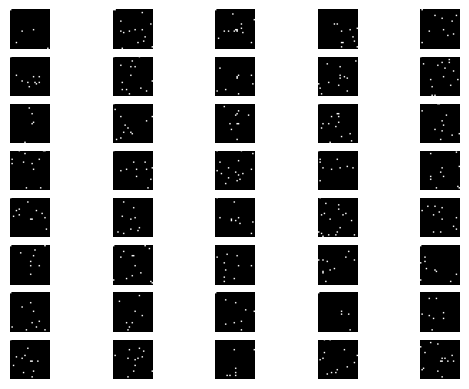

Mean p(x) on test set: 0.000000


In [19]:
with torch.no_grad():
    model_best = torch.load('NADERnn.model')
    num_x = 8
    num_y = 5
    x = model_best.sample(num_samples=num_x * num_y)
    x = x[0].cpu().detach().numpy()  # Move tensor to CPU before converting to numpy
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to('cuda')  # Flatten and move to correct device
        _, log_px = model_best.evalP(x)
        px_list.append(log_px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {torch.exp(px_all).mean().item():.6f}")

In [20]:
class CausalConv1d(nn.Module):

    """
    A causal 1D convolution.
    Implementation from Tomczak.
    """
    def __init__(self, in_channels, out_channels, kernel_size, dilation,exclude_current=False, **kwargs):
        super(CausalConv1d, self).__init__()
        # attributes:
        self.kernel_size = kernel_size
        self.dilation = dilation
        self.exclude_current = exclude_current
        self.padding = (kernel_size - 1) * dilation + (1 if exclude_current else 0) * dilation
        # module:
        self.conv1d = torch.nn.Conv1d(in_channels, out_channels,
                                      kernel_size, stride=1,
                                      padding=0,
                                      dilation=dilation,
                                      **kwargs)

    def forward(self, x):
        # Here is the trick!
        x = torch.nn.functional.pad(x, (self.padding, 0))
        conv1d_out = self.conv1d(x)
        if self.exclude_current:
            return conv1d_out[:, :, : -1]
        else:
            return conv1d_out

In [21]:
class CausalConvARM(nn.Module):
    def __init__(self, input_size=2):
        super(CausalConvARM, self).__init__()
        self.kernel_size = 11
        self.n_channels = 32
        self.sigmoid = nn.Sigmoid()
        self.net = nn.Sequential(
            CausalConv1d(in_channels=1, out_channels=self.n_channels,dilation=1, kernel_size=self.kernel_size, exclude_current=True, bias=True),
            nn.LeakyReLU(),
            CausalConv1d(in_channels=self.n_channels, out_channels=self.n_channels, dilation=2, kernel_size=self.kernel_size, exclude_current=False, bias=True),
            nn.LeakyReLU(),
            CausalConv1d(in_channels=self.n_channels, out_channels=self.n_channels, dilation=2, kernel_size=self.kernel_size, exclude_current=False, bias=True),
            nn.LeakyReLU(),
            CausalConv1d(in_channels=self.n_channels, out_channels=self.n_channels, dilation=1, kernel_size=self.kernel_size, exclude_current=False, bias=True)
        )
        # Define the logistic regression weights and bias
        self.lr_weights = torch.nn.Parameter(torch.zeros(input_size,self.n_channels))
        self.lr_bias = torch.nn.Parameter(torch.zeros(input_size))
        self.input_size = input_size

    def forward(self, x):
        h = self.net(x.unsqueeze(1))
        h = h.permute(0, 2, 1)
        sp= torch.sum(h*self.lr_weights,dim=2)+self.lr_bias
        return sp.squeeze(-1)

    def sample(self, num_samples):
        device = next(self.parameters()).device
        samples = torch.zeros(num_samples, self.input_size).to(device)
        probs = torch.zeros(num_samples, self.input_size).to(device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)
            probs[:, i] = prob[:,i]
            # Sample from the Bernoulli distribution
            samples[:, i] = torch.bernoulli(probs[:, i])
        return samples, probs
    # Calculate p(x) and log p(x) for a given input x
    def evalP(self, x):
        """
        Evaluate the probability p(x) for a given input x.
        x: torch.Tensor of shape [input_size] or [1, input_size]
        Returns: probability p(x) and log-probability log p(x)
        """
        if x.ndim == 1:
            x = x.unsqueeze(0)
        logits = self.forward(x)
        prob_vec = torch.sigmoid(logits)
        p_x = torch.prod(prob_vec * x + (1 - prob_vec) * (1 - x), dim=1)
        log_p_x = torch.sum(x * torch.log(prob_vec + 1e-8) + (1 - x) * torch.log(1 - prob_vec + 1e-8), dim=1)
        return p_x.squeeze(), log_p_x.squeeze()

In [22]:
# Train CausalConvARM model using Adam optimizer and binary cross-entropy loss on MNIST data
causalconvarm_model = CausalConvARM(input_size=D).to("cuda")
causalconvarm_optimizer = torch.optim.Adam(causalconvarm_model.parameters(), lr=lr)

# Training loop for CausalConvARM
num_epochs_causalconvarm = 500
train_models("CausalConvARM", num_epochs_causalconvarm, causalconvarm_model, causalconvarm_optimizer, training_loader)


CausalConvARM Epoch 000 Loss: 0.6226
CausalConvARM Epoch 001 Loss: 0.3214
CausalConvARM Epoch 002 Loss: 0.2954
CausalConvARM Epoch 003 Loss: 0.2823
CausalConvARM Epoch 004 Loss: 0.2678
CausalConvARM Epoch 005 Loss: 0.2572
CausalConvARM Epoch 006 Loss: 0.2359
CausalConvARM Epoch 007 Loss: 0.2107
CausalConvARM Epoch 008 Loss: 0.1907
CausalConvARM Epoch 009 Loss: 0.1798
CausalConvARM Epoch 010 Loss: 0.1727
CausalConvARM Epoch 011 Loss: 0.1656
CausalConvARM Epoch 012 Loss: 0.1598
CausalConvARM Epoch 013 Loss: 0.1556
CausalConvARM Epoch 014 Loss: 0.1518
CausalConvARM Epoch 015 Loss: 0.1482
CausalConvARM Epoch 016 Loss: 0.1449
CausalConvARM Epoch 017 Loss: 0.1421
CausalConvARM Epoch 018 Loss: 0.1398
CausalConvARM Epoch 019 Loss: 0.1380
CausalConvARM Epoch 020 Loss: 0.1365
CausalConvARM Epoch 021 Loss: 0.1353
CausalConvARM Epoch 022 Loss: 0.1342
CausalConvARM Epoch 023 Loss: 0.1333
CausalConvARM Epoch 024 Loss: 0.1324
CausalConvARM Epoch 025 Loss: 0.1315
CausalConvARM Epoch 026 Loss: 0.1307
C

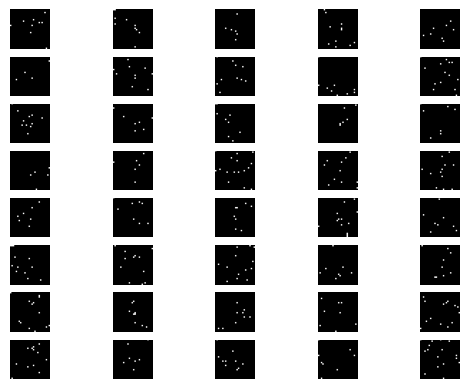

Mean p(x) on test set: 0.000000


In [23]:
with torch.no_grad():
    num_x = 8
    num_y = 5
    x = model_best.sample(num_samples=num_x * num_y)
    x = x[0].cpu().detach().numpy()  # Move tensor to CPU before converting to numpy
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to('cuda')  # Flatten and move to correct device
        _, log_px = model_best.evalP(x)
        px_list.append(log_px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {torch.exp(px_all).mean().item():.6f}")

# Problema 2

Consideramos una factorización bivarioada para el modelo NADE. Para hacerlo, proponemos que la salida sea la probabilidad de cada uno de los siguientes casos:
\begin{align}
(X_1,X_2) &= (0,0), & (X_1,X_2) &= (0,1)\\
(X_1,X_2) &= (1,0), & (X_1,X_2) &= (1,1)
\end{align}
La función de pérdida sigue siendo la entropía cruzada.

In [ ]:
class NADE(torch.nn.Module):

    def __init__(self, input_size, internal_size=512):
        super(NADE, self).__init__()
        self.input_size = input_size
        self.internal_size = internal_size
        self.register_buffer('autoregressive_mask', torch.tril(torch.ones(input_size, input_size), diagonal=-1))
        self.mlp_weights = torch.nn.Parameter(torch.zeros(self.internal_size,input_size))
        self.mlp_bias = torch.nn.Parameter(torch.zeros(self.internal_size))
        # Define the logistic regression weights and bias
        self.lr_weights = torch.nn.Parameter(torch.zeros(input_size,self.internal_size))
        self.lr_bias = torch.nn.Parameter(torch.zeros(input_size))
        nn.init.kaiming_normal_(self.mlp_weights)
        nn.init.kaiming_normal_(self.lr_weights)
        # Activation functions
        self.activation = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    # Forward pass of the model
    def forward(self, x):
        # We use a small epsilon to avoid log(0) issues
        epsilon = 0.00001
        # Forward pass evaluates the probability of an x given the alphas
        xn = self.autoregressive_mask*x.unsqueeze(1).repeat(1, self.input_size, 1) # Repeat x for input size
        # Random tensor of the same size as xn
        h = self.activation(nn.functional.linear(xn, self.mlp_weights,self.mlp_bias))
        # Logits
        sp = torch.sum(h*self.lr_weights,dim=2)+self.lr_bias
        return sp
    
    # Sample from the model
    def sample(self, num_samples):
        samples = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        probs = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)
            probs[:, i] = prob[:,i]
            # Sample from the Bernoulli distribution
            samples[:, i] = torch.bernoulli(probs[:, i])
        return samples, probs


    def evalP(self, x):
        # x: [num_samples, input_size] (observed images)
        probs = torch.zeros(x.shape[0], self.input_size).to(self.lr_weights.device)
        samples = torch.zeros_like(x).to(self.lr_weights.device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)[:, i]
            # Use the actual observed value for probability
            probs[:, i] = prob * x[:, i] + (1 - prob) * (1 - x[:, i])
            samples[:, i] = x[:, i]  # Set to observed value
        p_x = torch.prod(probs, dim=1)
        log_p_x = torch.sum(torch.log(probs + 1e-8), dim=1)
        return p_x, log_p_x

In [24]:
class BivariateNADE(nn.Module):
    """
    Bivariate NADE:
    Models p(x) as a product of joint categorical distributions over pixel pairs.
    Each pair (x_{2i-1}, x_{2i}) is modeled as a 4-way categorical conditioned on all earlier pixels.
    """
    def __init__(self, input_size, internal_size=512):
        super().__init__()
        # Ensure even input size (pairs of pixels)
        self.input_size = input_size if input_size % 2 == 0 else input_size + 1
        self.internal_size = internal_size
        self.n_pairs = self.input_size // 2
        # Autoregressive mask (lower triangular, no self-connections)
        mask = torch.tril(torch.ones(self.input_size, self.input_size), diagonal=-1)
        self.register_buffer("autoregressive_mask", mask)
        # First hidden layer (masked linear)
        self.fc1_weights = nn.Parameter(torch.empty(internal_size, self.input_size))
        self.fc1_bias = nn.Parameter(torch.zeros(internal_size))
        # Output layer: 4 logits per pair
        self.fc2_weights = nn.Parameter(torch.empty(self.n_pairs, 4, internal_size))
        self.fc2_bias = nn.Parameter(torch.zeros(self.n_pairs, 4))
        # Init
        nn.init.kaiming_normal_(self.fc1_weights)
        nn.init.kaiming_normal_(self.fc2_weights)
        self.activation = nn.Tanh()
    def forward(self, x):
        """
        Forward pass: returns logits for each pair.
        x: [batch, input_size]
        output: [batch, n_pairs, 4]
        """
        if x.shape[1] != self.input_size:
            pad = self.input_size - x.shape[1]
            x = F.pad(x, (0, pad), "constant", 0)
        # Masked linear (transpose mask to match weights shape, broadcast automatically)
        masked_w = self.fc1_weights * self.autoregressive_mask.T[:self.fc1_weights.shape[0], :]
        h = self.activation(F.linear(x, masked_w, self.fc1_bias))  # [batch, hidden]
        # Output logits for each pair
        logits = []
        for i in range(self.n_pairs):
            logit = F.linear(h, self.fc2_weights[i], self.fc2_bias[i])  # [batch, 4]
            logits.append(logit)
        logits = torch.stack(logits, dim=1)  # [batch, n_pairs, 4]
        return logits
    def sample(self, num_samples):
        """
        Sequentially sample pairs according to autoregressive ordering.
        """
        device = self.fc1_weights.device
        samples = torch.zeros(num_samples, self.input_size, device=device)
        for i in range(self.n_pairs):
            logits = self.forward(samples)  # [num_samples, n_pairs, 4]
            logits_pair = logits[:, i, :]   # [num_samples, 4]
            probs = F.softmax(logits_pair, dim=-1)
            # Sample categorical outcome
            idx = torch.multinomial(probs, 1).squeeze(1)  # [num_samples]
            pair = torch.stack([(idx >> 1) & 1, idx & 1], dim=1).float()  # [num_samples, 2]
            samples[:, 2*i:2*i+2] = pair
        return samples[:, :self.input_size]
    def evalP(self, x):
        """
        Evaluate probability p(x) and log p(x).
        """
        if x.ndim == 1:
            x = x.unsqueeze(0)
        if x.shape[1] != self.input_size:
            pad = self.input_size - x.shape[1]
            x = F.pad(x, (0, pad), "constant", 0)
        logits = self.forward(x)  # [batch, n_pairs, 4]
        probs = F.softmax(logits, dim=-1)
        p_x, log_p_x = [], []
        for b in range(x.shape[0]):
            px, logpx = 1.0, 0.0
            for i in range(self.n_pairs):
                pair = x[b, 2*i:2*i+2]
                idx = (pair[0].long() << 1) + pair[1].long()
                prob = probs[b, i, idx]
                px *= prob
                logpx += torch.log(prob + 1e-8)
            p_x.append(px)
            log_p_x.append(logpx)
        return torch.stack(p_x).squeeze(), torch.stack(log_p_x).squeeze()

In [25]:
# Train bivariateNADE model using Adam optimizer and cross-entropy loss on MNIST data
bivnade_model = BivariateNADE(input_size=D, internal_size=512).to("cuda")
bivnade_optimizer = torch.optim.Adam(bivnade_model.parameters(), lr=lr)

num_epochs_bivnade = 500

bv_min_loss = float('inf')
for epoch in range(num_epochs_bivnade):
    bivnade_model.train()
    for batch_idx, (x, y) in enumerate(training_loader):
        x = x.view(x.size(0), -1).to("cuda")  # Flatten MNIST images
        # Pad if needed
        if x.shape[1] % 2 != 0:
            x = F.pad(x, (0, 1), 'constant', 0)
        logits = bivnade_model(x)  # [batch, n_pairs, 4]
        # Prepare targets: for each pair, get index 0-3
        targets = []
        for i in range(bivnade_model.n_pairs):
            pair = x[:, 2*i:2*i+2]
            idx = (pair[:, 0].long() << 1) + pair[:, 1].long()
            targets.append(idx)
        targets = torch.stack(targets, dim=1)  # [batch, n_pairs]
        # Reshape logits and targets for cross-entropy
        logits_flat = logits.view(-1, 4)
        targets_flat = targets.view(-1)
        bv_loss = F.cross_entropy(logits_flat, targets_flat)
        bivnade_optimizer.zero_grad()
        bv_loss.backward()
        bivnade_optimizer.step()
        if bv_loss.item() < bv_min_loss:
            bv_min_loss = bv_loss.item()
            torch.save(bivnade_model, 'bivnade.model')
    print(f"Bivariate NADE Epoch {epoch:03d} Loss: {bv_loss.item():.4f}")

Bivariate NADE Epoch 000 Loss: 0.2275
Bivariate NADE Epoch 001 Loss: 0.0861
Bivariate NADE Epoch 002 Loss: 0.0752
Bivariate NADE Epoch 003 Loss: 0.0714
Bivariate NADE Epoch 004 Loss: 0.0694
Bivariate NADE Epoch 005 Loss: 0.0681
Bivariate NADE Epoch 006 Loss: 0.0672
Bivariate NADE Epoch 007 Loss: 0.0665
Bivariate NADE Epoch 008 Loss: 0.0658
Bivariate NADE Epoch 009 Loss: 0.0653
Bivariate NADE Epoch 010 Loss: 0.0648
Bivariate NADE Epoch 011 Loss: 0.0643
Bivariate NADE Epoch 012 Loss: 0.0639
Bivariate NADE Epoch 013 Loss: 0.0634
Bivariate NADE Epoch 014 Loss: 0.0630
Bivariate NADE Epoch 015 Loss: 0.0626
Bivariate NADE Epoch 016 Loss: 0.0622
Bivariate NADE Epoch 017 Loss: 0.0618
Bivariate NADE Epoch 018 Loss: 0.0614
Bivariate NADE Epoch 019 Loss: 0.0610
Bivariate NADE Epoch 020 Loss: 0.0607
Bivariate NADE Epoch 021 Loss: 0.0603
Bivariate NADE Epoch 022 Loss: 0.0599
Bivariate NADE Epoch 023 Loss: 0.0595
Bivariate NADE Epoch 024 Loss: 0.0592
Bivariate NADE Epoch 025 Loss: 0.0588
Bivariate NA

<ipython-input-30-55413bc5a8d4>:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_best = torch.load('bivnade.model')


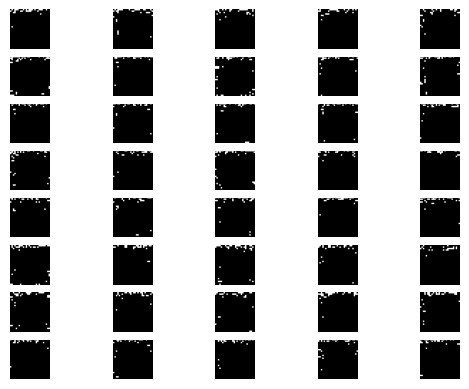

Mean p(x) on test set: 0.017172


In [30]:
with torch.no_grad():
    model_best = torch.load('bivnade.model')
    num_x = 8
    num_y = 5
    x = model_best.sample(num_samples=num_x * num_y)
    x = x.cpu().detach().numpy()
    fig, ax = plt.subplots(num_x, num_y)
    for i, ax in enumerate(ax.flatten()):
        plottable_image = np.reshape(x[i], (28, 28))
        ax.imshow(plottable_image, cmap='gray')
        ax.axis('off')

    plt.show()

    # Calculate p(x) for the test dataset using the trained model
    px_list = []
    for batch in testing_loader:
        x, _ = batch
        x = x.view(x.size(0), -1).to('cuda')  # Flatten and move to correct device
        px, _ = model_best.evalP(x)
        px_list.append(px.cpu())
    px_all = torch.cat(px_list)
    print(f"Mean p(x) on test set: {px_all.mean().item():.6f}")

# Problema 3

Añadimos la función fill a la clase de NADE, donde utilizamos una máscara para elegir si completamos un dígito o utilizamos el provisto. Por la implementación, es posible considerar imágenes con otra estructura faltante.

In [ ]:
class NADE(torch.nn.Module):

    def __init__(self, input_size, internal_size=512):
        super(NADE, self).__init__()
        self.input_size = input_size
        self.internal_size = internal_size
        self.register_buffer('autoregressive_mask', torch.tril(torch.ones(input_size, input_size), diagonal=-1))
        self.mlp_weights = torch.nn.Parameter(torch.zeros(self.internal_size,input_size))
        self.mlp_bias = torch.nn.Parameter(torch.zeros(self.internal_size))
        # Define the logistic regression weights and bias
        self.lr_weights = torch.nn.Parameter(torch.zeros(input_size,self.internal_size))
        self.lr_bias = torch.nn.Parameter(torch.zeros(input_size))
        nn.init.kaiming_normal_(self.mlp_weights)
        nn.init.kaiming_normal_(self.lr_weights)
        # Activation functions
        self.activation = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

    # Forward pass of the model
    def forward(self, x):
        # We use a small epsilon to avoid log(0) issues
        epsilon = 0.00001
        # Forward pass evaluates the probability of an x given the alphas
        xn = self.autoregressive_mask*x.unsqueeze(1).repeat(1, self.input_size, 1) # Repeat x for input size
        # Random tensor of the same size as xn
        h = self.activation(nn.functional.linear(xn, self.mlp_weights,self.mlp_bias))
        # Logits
        sp = torch.sum(h*self.lr_weights,dim=2)+self.lr_bias
        return sp
    
    # Sample from the model
    def sample(self, num_samples):
        samples = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        probs = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)
            probs[:, i] = prob[:,i]
            # Sample from the Bernoulli distribution
            samples[:, i] = torch.bernoulli(probs[:, i])
        return samples, probs


    def evalP(self, x):
        # x: [num_samples, input_size] (observed images)
        probs = torch.zeros(x.shape[0], self.input_size).to(self.lr_weights.device)
        samples = torch.zeros_like(x).to(self.lr_weights.device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)[:, i]
            # Use the actual observed value for probability
            probs[:, i] = prob * x[:, i] + (1 - prob) * (1 - x[:, i])
            samples[:, i] = x[:, i]  # Set to observed value
        p_x = torch.prod(probs, dim=1)
        log_p_x = torch.sum(torch.log(probs + 1e-8), dim=1)
        return p_x, log_p_x

    def fill(self, x_partial, mask=None):
        """
        Fill missing pixels in an image using the NADE model.
        Args:
            x_partial: [input_size] or [1, input_size], known pixels set, unknowns = 0 or any value.
            mask: same shape, 1=known, 0=unknown. If None, treat zeros as unknowns.
        Returns:
            x_filled: completed image
        """
        if x_partial.ndim == 1:
            x_partial = x_partial.unsqueeze(0)

        batch_size, input_size = x_partial.shape
        x_filled = x_partial.clone()

        if mask is None:
            mask = (x_partial != 0).float()

        for i in range(input_size):
            for b in range(batch_size):
                if mask[b, i] == 0:  # unknown pixel
                    logits = self.forward(x_filled[b:b+1])
                    prob = torch.sigmoid(logits)[0, i]
                    x_filled[b, i] = torch.bernoulli(prob)

        return x_filled.squeeze(0) if batch_size == 1 else x_filled


Cargamos el mejor modelo en vez de entrenar nuevamente.

In [32]:
# Train NADE model using Adam optimizer and binary cross-entropy loss on MNIST data
nade_model = NADE(input_size=D, internal_size=512).to("cuda")

# Load trained NADE model weights
nade_model.load_state_dict(torch.load('NADE.model').state_dict())
nade_model.eval()

<ipython-input-32-2c80e9794ed7>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  nade_model.load_state_dict(torch.load('NADE.model').state_dict())


NADE(
  (activation): Tanh()
)

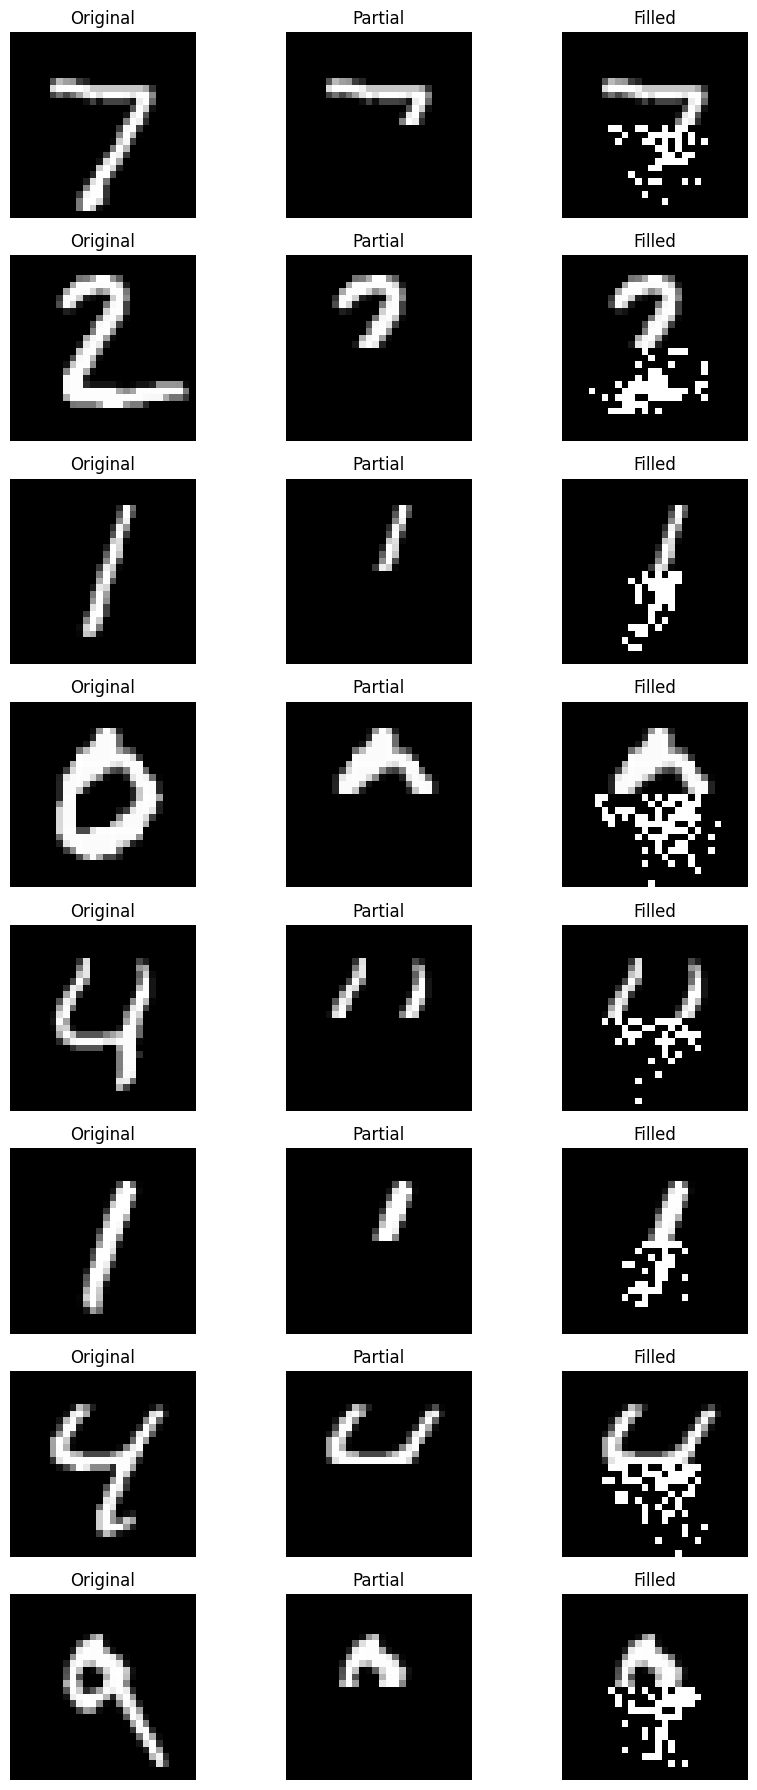

In [33]:
with torch.no_grad():
    # Get a batch from the testing dataset
    for batch in testing_loader:
        x, y = batch
        x = x.view(x.size(0), 28, 28)  # Reshape to [batch, 28, 28]
        # Only use the first 8 images for visualization
        x = x[:8]
        # Create partial images: keep first 14 rows, zero out the rest
        x_partial = x.clone()
        x_partial[:, 14:, :] = 0

        # Define a mask where known pixels are marked as 1 and unknown as 0
        mask = torch.ones_like(x)
        mask[:, 14:, :] = 0

        # Flatten for NADE input
        x_partial_flat = x_partial.view(x_partial.size(0), -1).to(nade_model.fc1_weights.device)
        mask_flat = mask.view(mask.size(0), -1).to(nade_model.fc1_weights.device)
        # Fill missing pixels
        x_filled_flat = nade_model.fill(x_partial_flat, mask = mask_flat)
        x_filled = x_filled_flat.cpu().numpy().reshape(-1, 28, 28)
        # Visualize original, partial, and filled images
        fig, axes = plt.subplots(8, 3, figsize=(9, 18))
        for i in range(8):
            axes[i, 0].imshow(x[i].cpu().numpy(), cmap='gray')
            axes[i, 0].set_title('Original')
            axes[i, 0].axis('off')
            axes[i, 1].imshow(x_partial[i].cpu().numpy(), cmap='gray')
            axes[i, 1].set_title('Partial')
            axes[i, 1].axis('off')
            axes[i, 2].imshow(x_filled[i], cmap='gray')
            axes[i, 2].set_title('Filled')
            axes[i, 2].axis('off')
        plt.tight_layout()
        plt.show()
        break  # Only process one batch

# Problema 4
Añadimos la posibilidad de permutar los datos, tanto al entrenamiento, como a la función de fill previamente creada. Proponemos las siguientes permutaciones:

- Recorrer verticalmente desde el inicio.
- Recorrer horizontalmente desde el último pixel
- Recorrer horizontalmente desde la fila central, hacia abajo y hacia arriba alternadamente
- Recorrer verticalmente desde la columna central, hacia la derecha e izquierda alternadamente
- Una espiral desde los extremos hacia el centro


In [ ]:
class NADE(torch.nn.Module):

    def __init__(self, input_size, internal_size=512, permutation=None):
        super(NADE, self).__init__()
        self.input_size = input_size
        self.internal_size = internal_size
        self.register_buffer('autoregressive_mask', torch.tril(torch.ones(input_size, input_size), diagonal=-1))
        self.mlp_weights = torch.nn.Parameter(torch.zeros(self.internal_size,input_size))
        self.mlp_bias = torch.nn.Parameter(torch.zeros(self.internal_size))
        # Define the logistic regression weights and bias
        self.lr_weights = torch.nn.Parameter(torch.zeros(input_size,self.internal_size))
        self.lr_bias = torch.nn.Parameter(torch.zeros(input_size))
        nn.init.kaiming_normal_(self.mlp_weights)
        nn.init.kaiming_normal_(self.lr_weights)
        # Activation functions
        self.activation = nn.Tanh()
        self.sigmoid = nn.Sigmoid()
        
        # Permutation: if None, identity
        if permutation is None:
            self.register_buffer("permutation", torch.arange(input_size))
        else:
            self.register_buffer("permutation", torch.tensor(permutation, dtype=torch.long))

    # Forward pass of the model
    def forward(self, x):
        # We use a small epsilon to avoid log(0) issues
        epsilon = 0.00001
        x_perm = x[:, self.permutation] if x.ndim == 2 else x[self.permutation]
        # Forward pass evaluates the probability of an x given the alphas
        xn = self.autoregressive_mask*x_perm.unsqueeze(1).repeat(1, self.input_size, 1) # Repeat x for input size
        # Random tensor of the same size as xn
        h = self.activation(nn.functional.linear(xn, self.mlp_weights,self.mlp_bias))
        # Logits
        sp = torch.sum(h*self.lr_weights,dim=2)+self.lr_bias
        # Inverse permutation before returning
        inv_perm = torch.argsort(self.permutation)
        return sp[:, inv_perm] if sp.ndim == 2 else sp[inv_perm]

    # Sample from the model
    def sample(self, num_samples):
        samples = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        probs = torch.zeros(num_samples, self.input_size).to(self.lr_weights.device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)
            probs[:, i] = prob[:,i]
            # Sample from the Bernoulli distribution
            samples[:, i] = torch.bernoulli(probs[:, i])
        return samples, probs


    def evalP(self, x):
        # x: [num_samples, input_size] (observed images)
        probs = torch.zeros(x.shape[0], self.input_size).to(self.lr_weights.device)
        samples = torch.zeros_like(x).to(self.lr_weights.device)
        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)[:, i]
            # Use the actual observed value for probability
            probs[:, i] = prob * x[:, i] + (1 - prob) * (1 - x[:, i])
            samples[:, i] = x[:, i]  # Set to observed value
        p_x = torch.prod(probs, dim=1)
        log_p_x = torch.sum(torch.log(probs + 1e-8), dim=1)
        return p_x, log_p_x

In [35]:
# p1: permutation for vertical (column-major) order for MNIST 28x28 images
p1 = [i + 28*j for i in range(28) for j in range(28)]
p1_nade_model = NADE(input_size=D, internal_size=512, permutation=p1).to("cuda")

p1_nade_optimizer = torch.optim.Adam(p1_nade_model.parameters(), lr=lr)

# Training loop for permutated NADEs
num_epochs_nade_p = 200

train_models('P1_NADE', num_epochs_nade_p, p1_nade_model, p1_nade_optimizer, training_loader)


P1_NADE Epoch 000 Loss: 0.3372
P1_NADE Epoch 001 Loss: 0.2911
P1_NADE Epoch 002 Loss: 0.2812
P1_NADE Epoch 003 Loss: 0.2770
P1_NADE Epoch 004 Loss: 0.2745
P1_NADE Epoch 005 Loss: 0.2727
P1_NADE Epoch 006 Loss: 0.2713
P1_NADE Epoch 007 Loss: 0.2701
P1_NADE Epoch 008 Loss: 0.2691
P1_NADE Epoch 009 Loss: 0.2681
P1_NADE Epoch 010 Loss: 0.2672
P1_NADE Epoch 011 Loss: 0.2664
P1_NADE Epoch 012 Loss: 0.2656
P1_NADE Epoch 013 Loss: 0.2648
P1_NADE Epoch 014 Loss: 0.2641
P1_NADE Epoch 015 Loss: 0.2633
P1_NADE Epoch 016 Loss: 0.2626
P1_NADE Epoch 017 Loss: 0.2620
P1_NADE Epoch 018 Loss: 0.2614
P1_NADE Epoch 019 Loss: 0.2609
P1_NADE Epoch 020 Loss: 0.2601
P1_NADE Epoch 021 Loss: 0.2597
P1_NADE Epoch 022 Loss: 0.2591
P1_NADE Epoch 023 Loss: 0.2585
P1_NADE Epoch 024 Loss: 0.2580
P1_NADE Epoch 025 Loss: 0.2573
P1_NADE Epoch 026 Loss: 0.2568
P1_NADE Epoch 027 Loss: 0.2565
P1_NADE Epoch 028 Loss: 0.2560
P1_NADE Epoch 029 Loss: 0.2554
P1_NADE Epoch 030 Loss: 0.2548
P1_NADE Epoch 031 Loss: 0.2544
P1_NADE 

In [34]:
class NADE(torch.nn.Module):
    """
    Neural Autoregressive Distribution Estimator (NADE) with optional permutation.
    Models p(x) = ∏ p(x_i | x_{π(<i)}), where π is a permutation of variables.
    """
    def __init__(self, input_size, internal_size=512, permutation=None):
        super().__init__()
        self.input_size = input_size
        self.internal_size = internal_size

        # Register autoregressive mask
        mask = torch.tril(torch.ones(input_size, input_size), diagonal=-1)
        self.register_buffer("autoregressive_mask", mask)

        # Parameters
        self.mlp_weights = nn.Parameter(torch.empty(internal_size, input_size))
        self.mlp_bias = nn.Parameter(torch.zeros(internal_size))
        self.lr_weights = nn.Parameter(torch.empty(input_size, internal_size))
        self.lr_bias = nn.Parameter(torch.zeros(input_size))

        # Initialization
        nn.init.kaiming_normal_(self.mlp_weights)
        nn.init.kaiming_normal_(self.lr_weights)

        # Nonlinearities
        self.activation = nn.Tanh()
        self.sigmoid = nn.Sigmoid()

        # Permutation: if None, identity
        if permutation is None:
            self.register_buffer("permutation", torch.arange(input_size))
        else:
            self.register_buffer("permutation", torch.tensor(permutation, dtype=torch.long))

    def forward(self, x):
        # Apply permutation
        x_perm = x[:, self.permutation] if x.ndim == 2 else x[self.permutation]

        # Masked input-to-hidden (matrix multiplication)
        masked_w = self.mlp_weights @ self.autoregressive_mask.T  # [hidden, input]
        h = self.activation(F.linear(x_perm, masked_w, self.mlp_bias))  # [batch, hidden]

        # Hidden-to-output
        logits = F.linear(h, self.lr_weights, self.lr_bias)  # [batch, input]
        return logits

    def sample(self, num_samples):
        samples = torch.zeros(num_samples, self.input_size, device=self.lr_weights.device)
        probs = torch.zeros_like(samples)

        for i in range(self.input_size):
            logits = self.forward(samples)
            prob = self.sigmoid(logits)
            probs[:, i] = prob[:, i]
            samples[:, i] = torch.bernoulli(probs[:, i])

        # Inverse permutation
        inv_perm = torch.argsort(self.permutation)
        return samples[:, inv_perm], probs[:, inv_perm]

    def evalP(self, x):
        if x.ndim == 1:
            x = x.unsqueeze(0)
        x_perm = x[:, self.permutation]
        logits = self.forward(x_perm)
        prob_vec = self.sigmoid(logits)
        # Probability and log-probability
        p_x = torch.prod(prob_vec * x_perm + (1 - prob_vec) * (1 - x_perm), dim=1)
        log_p_x = torch.sum(
            x_perm * torch.log(prob_vec + 1e-8) +
            (1 - x_perm) * torch.log(1 - prob_vec + 1e-8),
            dim=1
        )
        return p_x.squeeze(), log_p_x.squeeze()

    def fill(self, x_partial, mask=None):
        """
        Complete missing entries in x_partial (zeros or masked positions).
        """
        if x_partial.ndim == 1:
            x_partial = x_partial.unsqueeze(0)
        batch_size, input_size = x_partial.shape

        x_filled = x_partial.clone()
        if mask is None:
            mask = (x_partial != 0).float()

        # Permute input and mask
        x_filled_perm = x_filled[:, self.permutation].clone()
        mask_perm = mask[:, self.permutation].clone()

        for i in range(input_size):
            missing = (mask_perm[:, i] == 0)
            if missing.any():
                logits = self.forward(x_filled_perm)
                probs = self.sigmoid(logits)[:, i]
                x_filled_perm[missing, i] = torch.bernoulli(probs[missing])
                mask_perm[missing, i] = 1

        # Inverse permutation
        inv_perm = torch.argsort(self.permutation)
        x_filled_final = x_filled_perm[:, inv_perm]
        return x_filled_final.squeeze(0) if batch_size == 1 else x_filled_final


In [36]:
# p2: reverse permutation (from end to beginning)
p2 = list(reversed(range(D)))
p2_nade_model = NADE(input_size=D, internal_size=512, permutation=p2).to("cuda")

p2_nade_optimizer = torch.optim.Adam(p2_nade_model.parameters(), lr=lr)

train_models('P2_NADE', num_epochs_nade_p, p2_nade_model, p2_nade_optimizer, training_loader)


P2_NADE Epoch 000 Loss: 0.3396
P2_NADE Epoch 001 Loss: 0.2915
P2_NADE Epoch 002 Loss: 0.2815
P2_NADE Epoch 003 Loss: 0.2774
P2_NADE Epoch 004 Loss: 0.2750
P2_NADE Epoch 005 Loss: 0.2732
P2_NADE Epoch 006 Loss: 0.2715
P2_NADE Epoch 007 Loss: 0.2701
P2_NADE Epoch 008 Loss: 0.2688
P2_NADE Epoch 009 Loss: 0.2675
P2_NADE Epoch 010 Loss: 0.2664
P2_NADE Epoch 011 Loss: 0.2653
P2_NADE Epoch 012 Loss: 0.2643
P2_NADE Epoch 013 Loss: 0.2634
P2_NADE Epoch 014 Loss: 0.2625
P2_NADE Epoch 015 Loss: 0.2617
P2_NADE Epoch 016 Loss: 0.2609
P2_NADE Epoch 017 Loss: 0.2601
P2_NADE Epoch 018 Loss: 0.2594
P2_NADE Epoch 019 Loss: 0.2586
P2_NADE Epoch 020 Loss: 0.2580
P2_NADE Epoch 021 Loss: 0.2573
P2_NADE Epoch 022 Loss: 0.2564
P2_NADE Epoch 023 Loss: 0.2557
P2_NADE Epoch 024 Loss: 0.2549
P2_NADE Epoch 025 Loss: 0.2541
P2_NADE Epoch 026 Loss: 0.2535
P2_NADE Epoch 027 Loss: 0.2528
P2_NADE Epoch 028 Loss: 0.2521
P2_NADE Epoch 029 Loss: 0.2515
P2_NADE Epoch 030 Loss: 0.2509
P2_NADE Epoch 031 Loss: 0.2503
P2_NADE 

In [37]:
# p3: custom permutation starting from row 13, then 14, then 12, then 15, ...
rows = []
for offset in range(28):
    if offset % 2 == 0:
        rows.append(13 + offset//2)
    else:
        rows.append(13 - (offset+1)//2)
p3 = [r*28 + c for c in range(28) for r in rows]
p3_nade_model = NADE(input_size=D, internal_size=512, permutation=p3).to("cuda")

p3_nade_optimizer = torch.optim.Adam(p3_nade_model.parameters(), lr=lr)

train_models('P3_NADE', num_epochs_nade_p, p3_nade_model, p3_nade_optimizer, training_loader)

P3_NADE Epoch 000 Loss: 0.3490
P3_NADE Epoch 001 Loss: 0.2934
P3_NADE Epoch 002 Loss: 0.2819
P3_NADE Epoch 003 Loss: 0.2769
P3_NADE Epoch 004 Loss: 0.2739
P3_NADE Epoch 005 Loss: 0.2718
P3_NADE Epoch 006 Loss: 0.2703
P3_NADE Epoch 007 Loss: 0.2690
P3_NADE Epoch 008 Loss: 0.2679
P3_NADE Epoch 009 Loss: 0.2669
P3_NADE Epoch 010 Loss: 0.2661
P3_NADE Epoch 011 Loss: 0.2654
P3_NADE Epoch 012 Loss: 0.2647
P3_NADE Epoch 013 Loss: 0.2641
P3_NADE Epoch 014 Loss: 0.2634
P3_NADE Epoch 015 Loss: 0.2628
P3_NADE Epoch 016 Loss: 0.2621
P3_NADE Epoch 017 Loss: 0.2615
P3_NADE Epoch 018 Loss: 0.2609
P3_NADE Epoch 019 Loss: 0.2604
P3_NADE Epoch 020 Loss: 0.2598
P3_NADE Epoch 021 Loss: 0.2593
P3_NADE Epoch 022 Loss: 0.2589
P3_NADE Epoch 023 Loss: 0.2583
P3_NADE Epoch 024 Loss: 0.2578
P3_NADE Epoch 025 Loss: 0.2573
P3_NADE Epoch 026 Loss: 0.2569
P3_NADE Epoch 027 Loss: 0.2564
P3_NADE Epoch 028 Loss: 0.2561
P3_NADE Epoch 029 Loss: 0.2557
P3_NADE Epoch 030 Loss: 0.2553
P3_NADE Epoch 031 Loss: 0.2549
P3_NADE 

In [38]:
# p4: custom permutation starting from column 13, then 14, then 12, then 15, ...
cols = []
for offset in range(28):
    if offset % 2 == 0:
        cols.append(13 + offset//2)
    else:
        cols.append(13 - (offset+1)//2)
p4 = [r*28 + c for r in range(28) for c in cols]
p4_nade_model = NADE(input_size=D, internal_size=512, permutation=p4).to("cuda")

p4_nade_optimizer = torch.optim.Adam(p4_nade_model.parameters(), lr=lr)

train_models('P4_NADE', num_epochs_nade_p, p4_nade_model, p4_nade_optimizer, training_loader)

P4_NADE Epoch 000 Loss: 0.3467
P4_NADE Epoch 001 Loss: 0.2928
P4_NADE Epoch 002 Loss: 0.2821
P4_NADE Epoch 003 Loss: 0.2777
P4_NADE Epoch 004 Loss: 0.2750
P4_NADE Epoch 005 Loss: 0.2731
P4_NADE Epoch 006 Loss: 0.2715
P4_NADE Epoch 007 Loss: 0.2701
P4_NADE Epoch 008 Loss: 0.2688
P4_NADE Epoch 009 Loss: 0.2677
P4_NADE Epoch 010 Loss: 0.2666
P4_NADE Epoch 011 Loss: 0.2656
P4_NADE Epoch 012 Loss: 0.2646
P4_NADE Epoch 013 Loss: 0.2636
P4_NADE Epoch 014 Loss: 0.2627
P4_NADE Epoch 015 Loss: 0.2619
P4_NADE Epoch 016 Loss: 0.2612
P4_NADE Epoch 017 Loss: 0.2604
P4_NADE Epoch 018 Loss: 0.2598
P4_NADE Epoch 019 Loss: 0.2591
P4_NADE Epoch 020 Loss: 0.2585
P4_NADE Epoch 021 Loss: 0.2580
P4_NADE Epoch 022 Loss: 0.2574
P4_NADE Epoch 023 Loss: 0.2569
P4_NADE Epoch 024 Loss: 0.2563
P4_NADE Epoch 025 Loss: 0.2558
P4_NADE Epoch 026 Loss: 0.2552
P4_NADE Epoch 027 Loss: 0.2548
P4_NADE Epoch 028 Loss: 0.2541
P4_NADE Epoch 029 Loss: 0.2536
P4_NADE Epoch 030 Loss: 0.2531
P4_NADE Epoch 031 Loss: 0.2525
P4_NADE 

In [39]:
# p5: concentric circles (spiral) permutation for MNIST 28x28 images
def spiral_permutation(n):
    perm = []
    left, right, top, bottom = 0, n-1, 0, n-1
    while left <= right and top <= bottom:
        # Top row (left to right)
        for c in range(left, right+1):
            perm.append(top*n + c)
        top += 1
        # Right column (top to bottom)
        for r in range(top, bottom+1):
            perm.append(r*n + right)
        right -= 1
        # Bottom row (right to left)
        if top <= bottom:
            for c in range(right, left-1, -1):
                perm.append(bottom*n + c)
            bottom -= 1
        # Left column (bottom to top)
        if left <= right:
            for r in range(bottom, top-1, -1):
                perm.append(r*n + left)
            left += 1
    return perm
p5 = spiral_permutation(28)
p5_nade_model = NADE(input_size=D, internal_size=512, permutation=p5).to("cuda")


p5_nade_optimizer = torch.optim.Adam(p5_nade_model.parameters(), lr=lr)

train_models('P5_NADE', num_epochs_nade_p, p5_nade_model, p5_nade_optimizer, training_loader)


P5_NADE Epoch 000 Loss: 0.3467
P5_NADE Epoch 001 Loss: 0.2936
P5_NADE Epoch 002 Loss: 0.2828
P5_NADE Epoch 003 Loss: 0.2788
P5_NADE Epoch 004 Loss: 0.2767
P5_NADE Epoch 005 Loss: 0.2754
P5_NADE Epoch 006 Loss: 0.2745
P5_NADE Epoch 007 Loss: 0.2738
P5_NADE Epoch 008 Loss: 0.2732
P5_NADE Epoch 009 Loss: 0.2728
P5_NADE Epoch 010 Loss: 0.2725
P5_NADE Epoch 011 Loss: 0.2721
P5_NADE Epoch 012 Loss: 0.2716
P5_NADE Epoch 013 Loss: 0.2711
P5_NADE Epoch 014 Loss: 0.2705
P5_NADE Epoch 015 Loss: 0.2701
P5_NADE Epoch 016 Loss: 0.2697
P5_NADE Epoch 017 Loss: 0.2694
P5_NADE Epoch 018 Loss: 0.2690
P5_NADE Epoch 019 Loss: 0.2686
P5_NADE Epoch 020 Loss: 0.2683
P5_NADE Epoch 021 Loss: 0.2681
P5_NADE Epoch 022 Loss: 0.2678
P5_NADE Epoch 023 Loss: 0.2675
P5_NADE Epoch 024 Loss: 0.2673
P5_NADE Epoch 025 Loss: 0.2669
P5_NADE Epoch 026 Loss: 0.2667
P5_NADE Epoch 027 Loss: 0.2664
P5_NADE Epoch 028 Loss: 0.2663
P5_NADE Epoch 029 Loss: 0.2660
P5_NADE Epoch 030 Loss: 0.2657
P5_NADE Epoch 031 Loss: 0.2655
P5_NADE 

<ipython-input-41-7c515a9fb0d1>:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f'{name}.model')


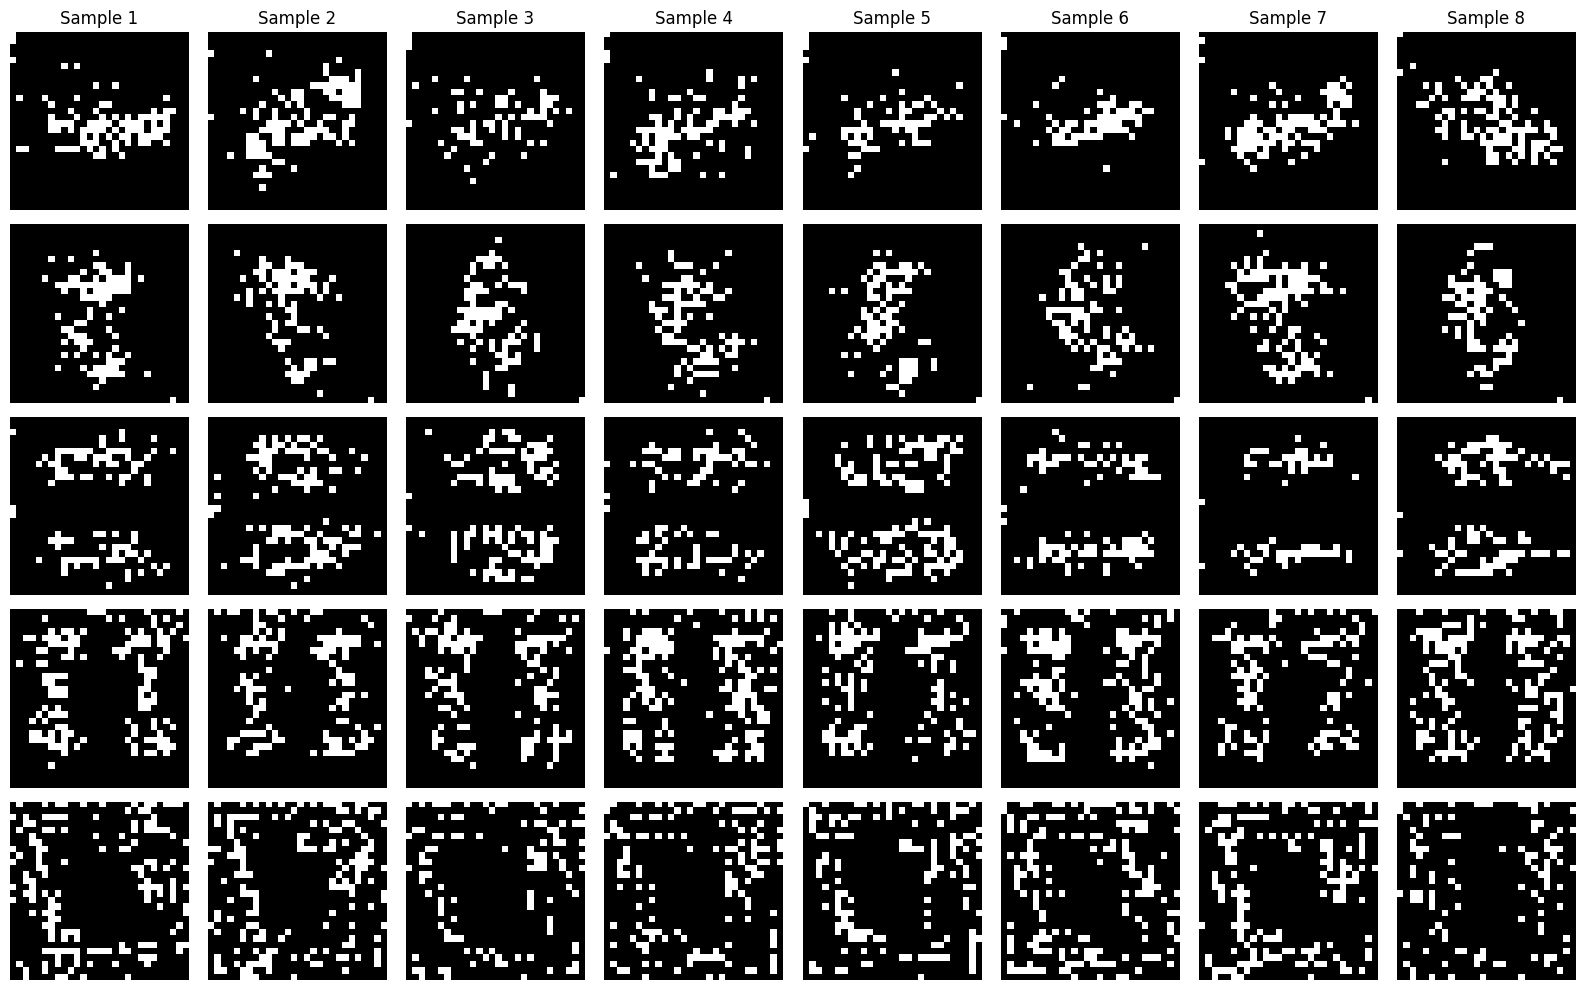

P1_NADE: Mean log p(x) on test set = -18.4207
P2_NADE: Mean log p(x) on test set = -18.4207
P3_NADE: Mean log p(x) on test set = -18.4207
P4_NADE: Mean log p(x) on test set = -18.4207
P5_NADE: Mean log p(x) on test set = -18.4207


In [41]:
with torch.no_grad():
    # Load all permuted NADE models
    nade_models = []
    model_names = ['P1_NADE', 'P2_NADE', 'P3_NADE', 'P4_NADE', 'P5_NADE']
    for name in model_names:
        model = torch.load(f'{name}.model')
        model.eval()
        nade_models.append(model)

    # Generate 8 samples for each model
    num_samples = 8
    fig, axes = plt.subplots(len(nade_models), num_samples, figsize=(num_samples*2, len(nade_models)*2))
    for i, model in enumerate(nade_models):
        samples, _ = model.sample(num_samples)
        samples = samples.cpu().numpy().reshape(-1, 28, 28)
        for j in range(num_samples):
            axes[i, j].imshow(samples[j], cmap='gray')
            axes[i, j].axis('off')
            if i == 0:
                axes[i, j].set_title(f"Sample {j+1}")
        axes[i, 0].set_ylabel(model_names[i], rotation=0, labelpad=40, fontsize=12)

    plt.tight_layout()
    plt.show()

    # Calculate p(x) for the test dataset for each model
    px_results = {}
    for i, model in enumerate(nade_models):
        px_list = []
        for batch in testing_loader:
            x, _ = batch
            x = x.view(x.size(0), -1).to('cuda')
            px, _ = model.evalP(x)
            px_list.append(px.cpu())
        px_all = torch.cat(px_list)
        px_results[model_names[i]] = px_all

    # Print mean log p(x) for each model
    for name in model_names:
        mean_log_px = torch.log(px_results[name] + 1e-8).mean().item()
        print(f"{name}: Mean log p(x) on test set = {mean_log_px:.4f}")